# Projet REXIA -- Responsible and Explainable AI

## Partie 1/3 : Donnees tabulaires

Analyse du jeu de donnees RH anonymise. La variable cible `label` indique :
- **0** : l'employe n'a pas demissionne dans les 6 prochains mois
- **1** : l'employe a demissionne dans les 6 prochains mois

## 0. Imports et configuration

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -- Configuration globale des graphiques --
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
DATA_PATH = "../data/RH_dataset.csv"
CSV_SEPARATOR = ";"

LABEL_COL = "label"
LABEL_NAMES = {0: "Non-demission", 1: "Demission"}

## Fonctions utilitaires

In [27]:
def load_dataset(path: str, separator: str = ";") -> pd.DataFrame:
    """Charge le jeu de donnees CSV et retourne un DataFrame."""
    return pd.read_csv(path, sep=separator)


def plot_countplot(
    data: pd.DataFrame,
    column: str,
    title: str,
    hue: str | None = None,
    rotate_labels: int = 0,
    figsize: tuple[int, int] = (12, 5),
    order: list | None = None,
) -> None:
    """Affiche un diagramme en barres pour une colonne categorielle."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.countplot(data=data, x=column, hue=hue, order=order, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("Effectif")
    if rotate_labels:
        ax.tick_params(axis="x", rotation=rotate_labels)
    plt.tight_layout()
    plt.show()


def plot_distribution(
    data: pd.DataFrame,
    column: str,
    title: str,
    hue: str | None = None,
    bins: int = 30,
    figsize: tuple[int, int] = (12, 5),
) -> None:
    """Affiche un histogramme avec courbe de densite pour une colonne numerique."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(data=data, x=column, hue=hue, bins=bins, kde=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("Effectif")
    plt.tight_layout()
    plt.show()


def plot_boxplot_by_label(
    data: pd.DataFrame,
    column: str,
    label_col: str = LABEL_COL,
    title: str = "",
    figsize: tuple[int, int] = (10, 5),
) -> None:
    """Affiche un boxplot d'une variable numerique ventile par la variable cible."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=data, x=label_col, y=column, ax=ax)
    ax.set_title(title or f"Distribution de '{column}' par classe")
    ax.set_xlabel("Classe (label)")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()


def display_summary_table(data: pd.DataFrame) -> pd.DataFrame:
    """Retourne un DataFrame recapitulatif : type, nb valeurs uniques, min, max, manquantes."""
    summary = pd.DataFrame({
        "Type": data.dtypes,
        "Valeurs uniques": data.nunique(),
        "Valeurs manquantes": data.isnull().sum(),
        "% manquantes": (data.isnull().sum() / len(data) * 100).round(2),
        "Exemple": data.iloc[0],
    })
    return summary

---
## 1. Analyse du jeu de données

### 1.1 Chargement et aperçu général

In [8]:
df = load_dataset(DATA_PATH, CSV_SEPARATOR)

print(f"Dimensions du jeu de donnees : {df.shape[0]} lignes, {df.shape[1]} colonnes\n")
df.head(10)

Dimensions du jeu de donnees : 23857 lignes, 14 colonnes



,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0
5,Production,30.410000,29.049999,3.350000,4.290000,28,40,1,1,3510,PACS,1,2642,0
6,Commercial/Business,13.840000,32.410000,8.890000,42.509998,28,72,1,3,7223,Marié(e),1,318,0
7,Etudes & Technique,34.799999,22.790001,9.480000,10.580000,28,45,1,2,4132,Marié(e),1,2132,0
8,Etudes & Technique,80.220001,24.180000,8.090000,35.349998,28,65,0,2,4773,Divorcé(e),1,880,0
9,Etudes & Technique,5.190000,2.780000,1.420000,10.100000,28,42,0,2,4517,Union libre,1,676,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  object 
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  object 
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  l

Il n'y a pas de données manquantes.

In [28]:
display_summary_table(df)

,Type,Valeurs uniques,Valeurs manquantes,% manquantes,Exemple
Famille d'emploi,object,8,0,0.0,Production
Dernière promotion (mois),float64,7670,0,0.0,8.51
Dernière augmentation (mois),float64,2934,0,0.0,7.9
Début de contrat (années),float64,2433,0,0.0,0.91
Ancienneté groupe (années),float64,3660,0,0.0,0.97
Etablissement,int64,35,0,0.0,27
Âge (années),int64,74,0,0.0,30
Parent,int64,2,0,0.0,1
Niveau hiérarchique,int64,4,0,0.0,1
Salaire (Euros),int64,4901,0,0.0,3199


In [ ]:
df.describe().round(2)

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00
mean,29.46,7.93,7.53,11.63,20.19,41.77,0.72,1.55,4168.40,0.51,1361.26,0.03
std,25.50,7.55,5.99,9.22,9.30,11.01,0.45,0.66,1657.83,0.50,794.18,0.18
min,0.00,0.00,0.00,0.00,0.00,20.00,0.00,1.00,2134.00,0.00,0.00,0.00
25%,10.59,3.18,2.30,3.80,11.00,34.00,0.00,1.00,3197.00,0.00,655.00,0.00
50%,21.22,5.88,6.28,9.87,26.00,41.00,1.00,1.00,3629.00,1.00,1371.00,0.00
75%,41.40,10.34,11.07,16.32,28.00,49.00,1.00,2.00,4511.00,1.00,2072.00,0.00
max,152.97,84.05,33.12,45.62,36.00,100.00,1.00,4.00,18137.00,2.00,2675.00,1.00


**Observations generales :**

- Le jeu de donnees contient **23 857 lignes** et **14 colonnes**. Il n'y a **aucune valeur manquante**.
- **Variables categorielles** (2) : `Famille d'emploi` (8 modalites), `Statut marital` (9 modalites).
- **Variables numeriques continues** (4) : `Derniere promotion (mois)`, `Derniere augmentation (mois)`, `Debut de contrat (annees)`, `Anciennete groupe (annees)`.
- **Variables numeriques discretes / binaires** : `Etablissement` (35 valeurs), `Age (annees)`, `Parent` (0/1), `Niveau hierarchique` (1-4), `Salaire (Euros)`, `Vehicule` (0/1 principalement, 4 cas a 2), `matricule` (identifiant unique), `label` (cible).
- La colonne `matricule` est un identifiant unique par employe : elle n'a aucun pouvoir predictif et devra etre exclue de toute modelisation.
- La colonne `Vehicule` contient 4 valeurs a 2, ce qui pourrait etre une erreur de saisie ou une modalite rare (par ex. "2 vehicules").

### 1.2 Desequilibre des classes

Repartition de la target:
  Classe 0 (Non-demission) : 23102 (96.84%)
  Classe 1 (Demission) : 755 (3.16%)


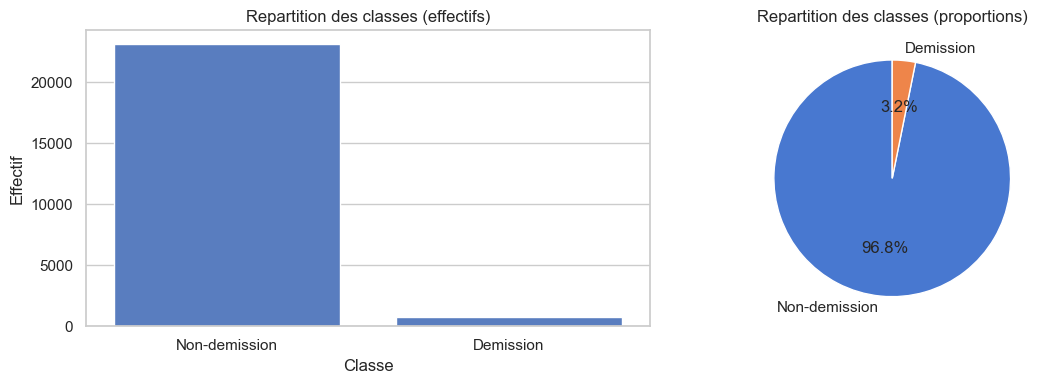

In [29]:
label_counts = df[LABEL_COL].value_counts()
label_pct = df[LABEL_COL].value_counts(normalize=True).mul(100).round(2)

print("Repartition de la target:")
for cls in label_counts.index:
    print(f"  Classe {cls} ({LABEL_NAMES[cls]}) : {label_counts[cls]} ({label_pct[cls]}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x=LABEL_COL, ax=axes[0])
axes[0].set_title("Repartition des classes (effectifs)")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Effectif")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels([LABEL_NAMES[0], LABEL_NAMES[1]])

axes[1].pie(
    label_counts.values,
    labels=[LABEL_NAMES[k] for k in label_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("muted", 2),
)
axes[1].set_title("Repartition des classes (proportions)")

plt.tight_layout()
plt.show()

Le jeu de données est très déséquilibré: seulement 3.2% des employes ont demissionnées (755 personnes) contre 96.8% qui n'ont pas demissionné (23 102 personnes).

On doit le prendre en compte pour la modélisation (sampling, class weight, metriques adaptees comme le F1-score ou l'AUC-ROC et éviter l'accuracy).

### 1.3 Exploration des variables categorielles

--- Famille d'emploi ---
  Nombre de modalites : 8
  Modalites : ['Production', 'Commercial/Business', 'Etudes & Technique', 'Support', 'IT', 'Développement Immobilier', 'Matériel/Equipement', 'Management']



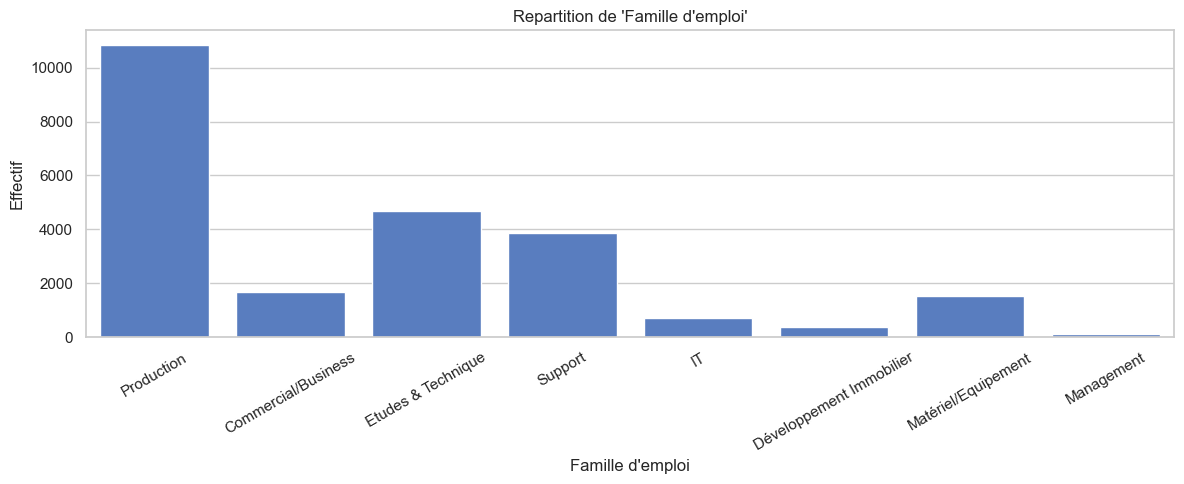

--- Statut marital ---
  Nombre de modalites : 9
  Modalites : ['Marié(e)', 'PACS', 'Célibataire', 'Divorcé(e)', 'Union libre', 'Concubin', 'Séparé(e)', 'Veuf(ve)', 'ex PACS']



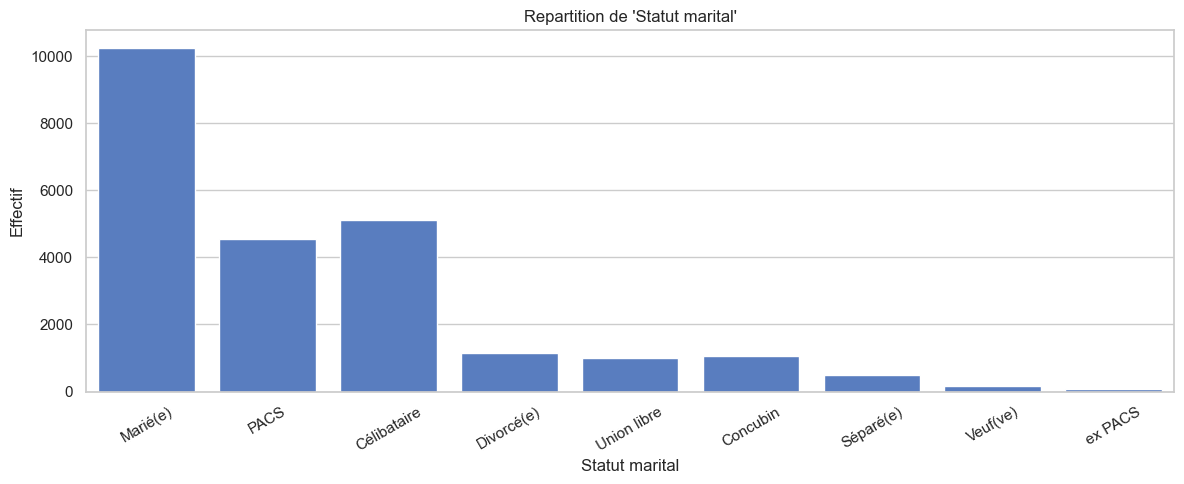

In [13]:
categorical_columns = ["Famille d'emploi", "Statut marital"]

for col in categorical_columns:
    print(f"--- {col} ---")
    print(f"  Nombre de modalites : {df[col].nunique()}")
    print(f"  Modalites : {df[col].unique().tolist()}")
    print()

    plot_countplot(
        data=df,
        column=col,
        title=f"Repartition de '{col}'",
        rotate_labels=30,
    )

Le concubinage et union libre nous semble être la même chose. Il faudra si c'est confirmé les regrouper dans la même catégorie.

**Commentaire :**

- **Famille d'emploi** : La famille Production est de loin la plus representee (10 800 employes), suivie de Etudes & Technique et Support. Management est tres minoritaire (132). Cette repartition reflete une structure industrielle classique.
- **Statut marital** : Les Marie(e)s representent la plus grande part (10 250 employés), suivis des Célibataires et des PACS. Les statuts Veuf(ve) et ex PACS sont rares.

### 1.4 Exploration des variables numeriques

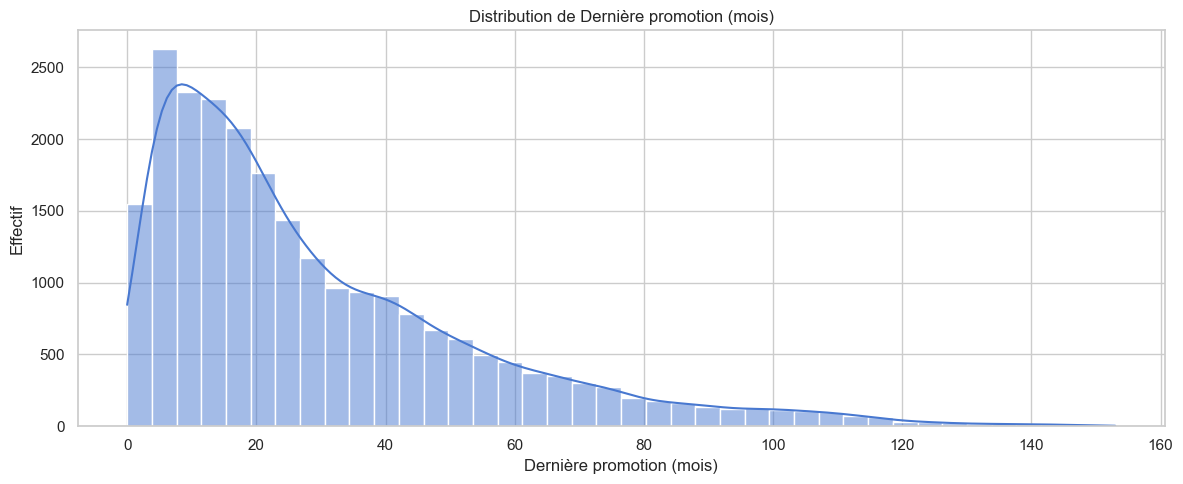

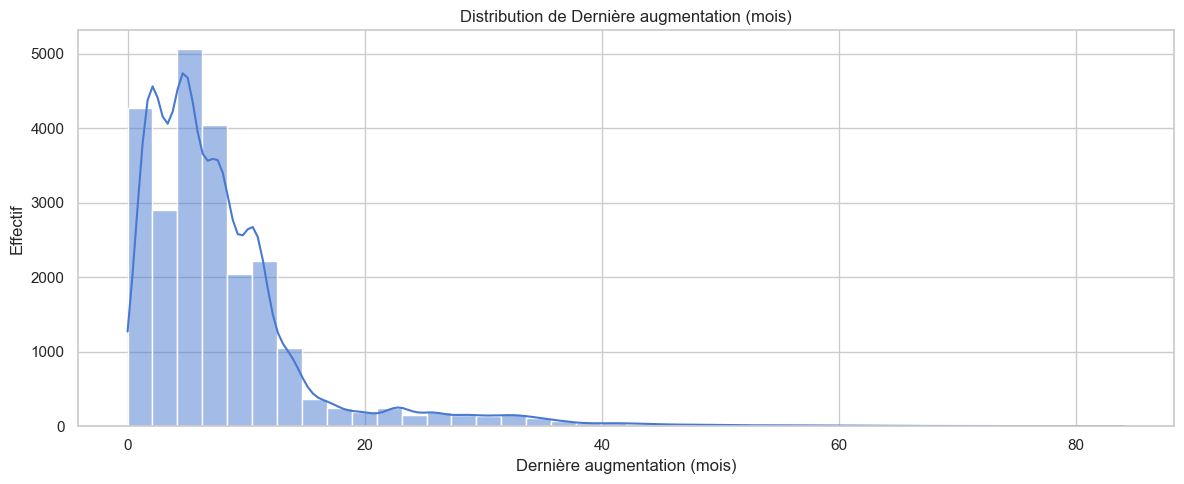

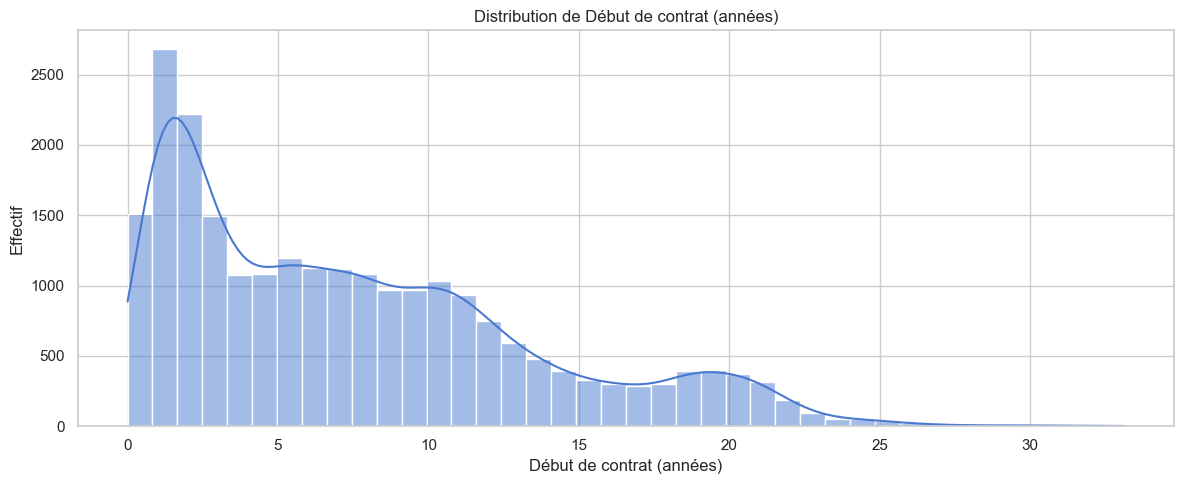

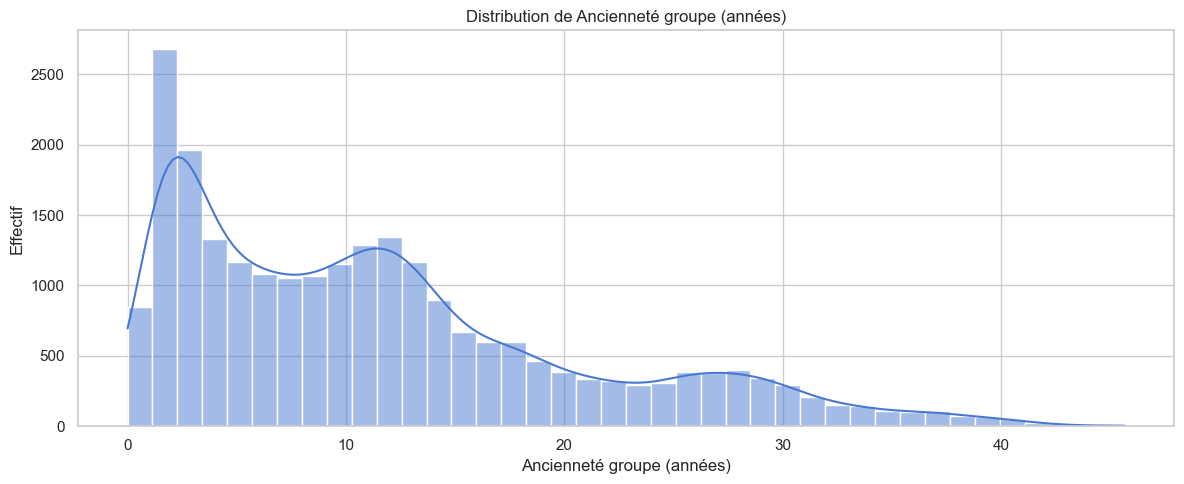

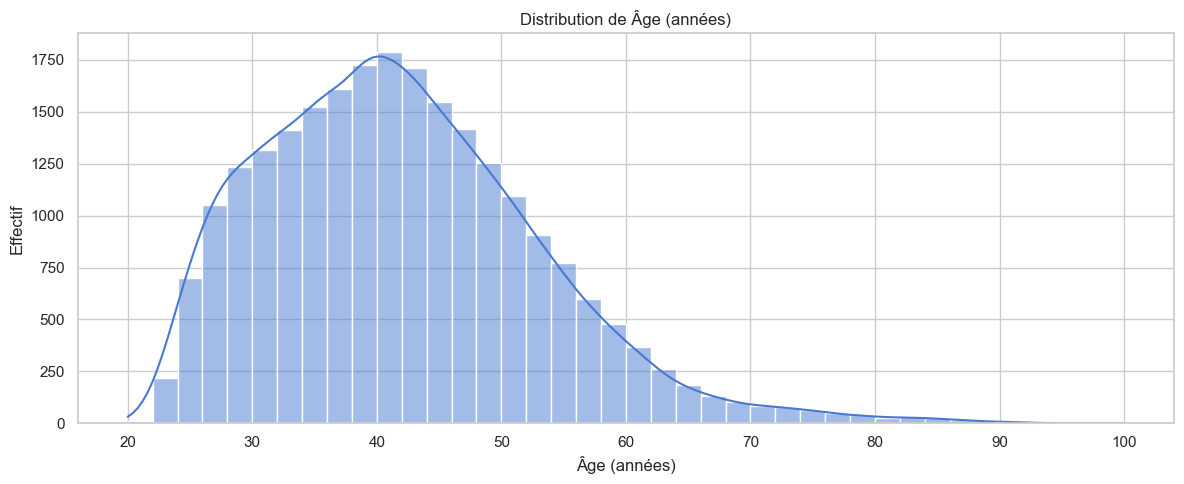

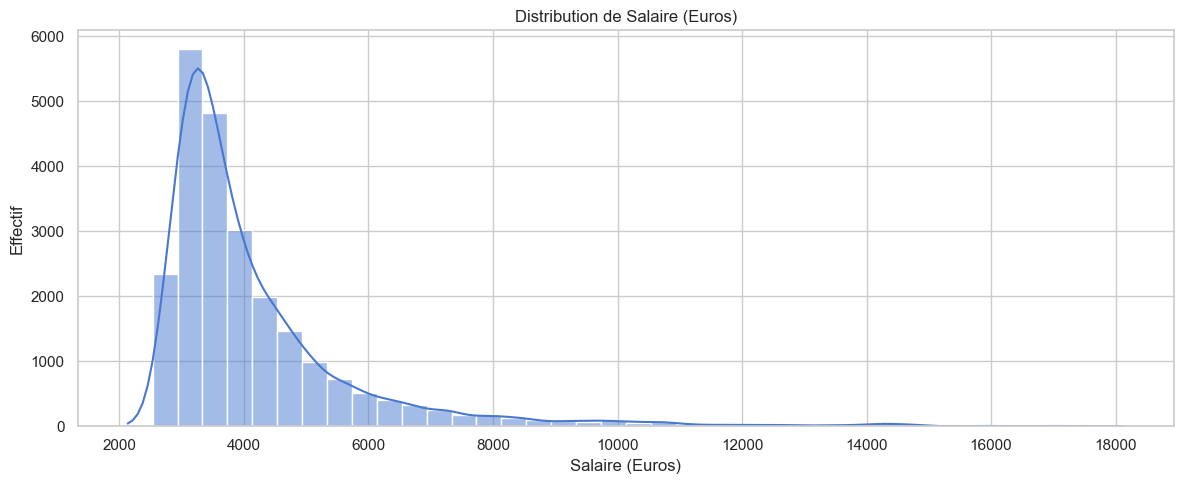

In [30]:
numerical_columns = [
    "Dernière promotion (mois)",
    "Dernière augmentation (mois)",
    "Début de contrat (années)",
    "Ancienneté groupe (années)",
    "Âge (années)",
    "Salaire (Euros)",
]

for col in numerical_columns:
    plot_distribution(
        data=df,
        column=col,
        title=f"Distribution de {col}",
        bins=40,
    )

--- Parent ---
  Valeurs uniques : [np.int64(0), np.int64(1)]
  Repartition :
Parent
0     6663
1    17194



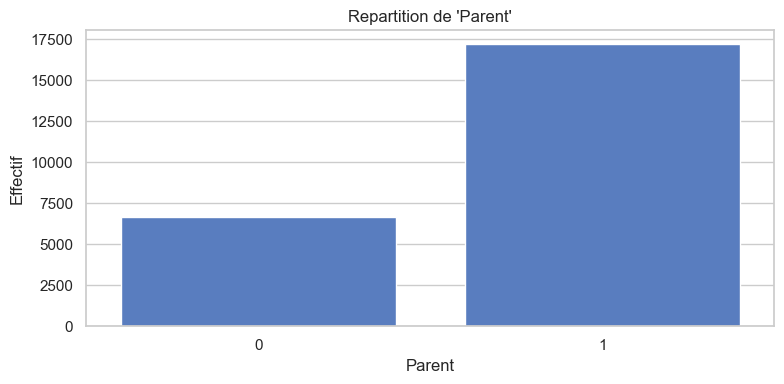

--- Niveau hiérarchique ---
  Valeurs uniques : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Repartition :
Niveau hiérarchique
1    12823
2     8858
3     2156
4       20



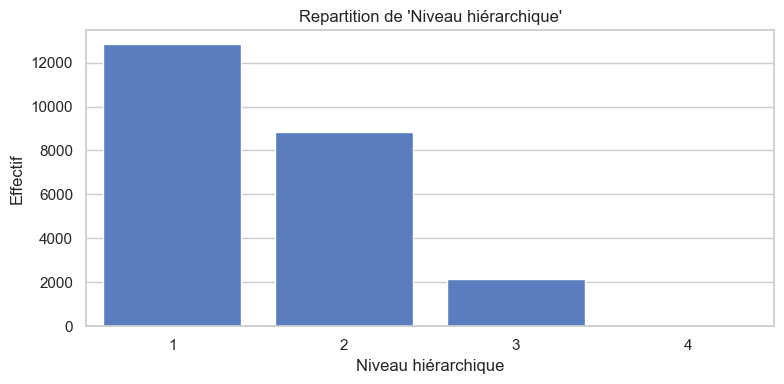

--- Véhicule ---
  Valeurs uniques : [np.int64(0), np.int64(1), np.int64(2)]
  Repartition :
Véhicule
0    11769
1    12084
2        4



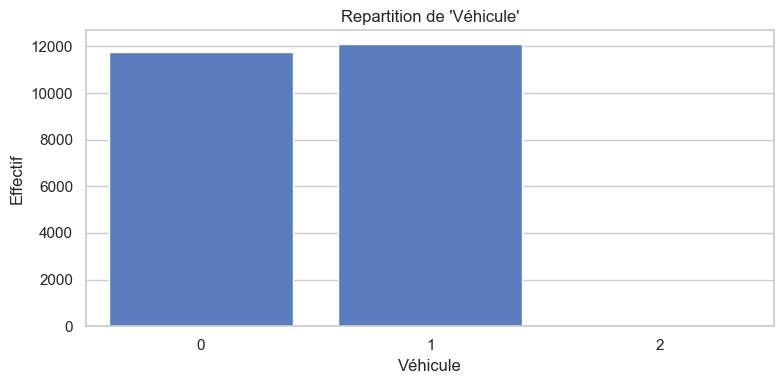

--- Etablissement ---
  Valeurs uniques : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]
  Repartition :
Etablissement
0       84
1      449
2      794
3      409
4      395
5      212
6      752
7      697
8      634
9      516
10     322
11     807
12     522
13     337
14     200
15     283
16     328
17     261
18     265
19     487
20     258
21     378
22     839
23     482
24     788
25     279
26     684
27    2807
28    8077
29     463
30      17
33       7
34      11
35       7
36       6



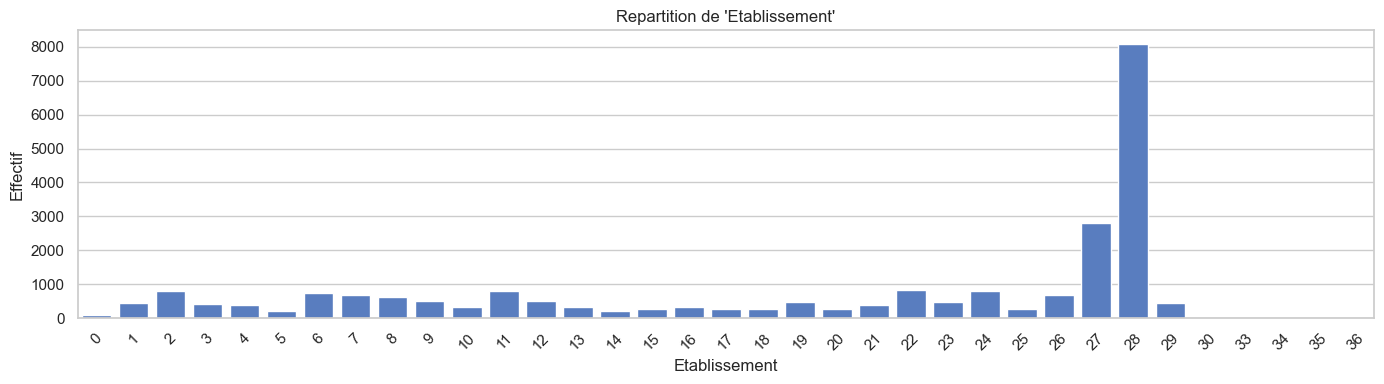

In [31]:
discrete_columns = ["Parent", "Niveau hiérarchique", "Véhicule", "Etablissement"]

for col in discrete_columns:
    print(f"--- {col} ---")
    print(f"  Valeurs uniques : {sorted(df[col].unique())}")
    print(f"  Repartition :")
    print(df[col].value_counts().sort_index().to_string())
    print()

    plot_countplot(
        data=df,
        column=col,
        title=f"Repartition de '{col}'",
        rotate_labels=45 if col == "Etablissement" else 0,
        figsize=(14, 4) if col == "Etablissement" else (8, 4),
    )

**Commentaire sur les variables numeriques :**

- **Derniere promotion (mois)** : Distribution etalee a droite (mediane ~21 mois, max ~153 mois). La plupart des promotions ont eu lieu recemment.
- **Derniere augmentation (mois)** : Concentree entre 0 et 25 mois, avec une moyenne a ~8 mois.
- **Debut de contrat (annees)** : Distribution etalee, de 0 (embauche recente) a 33 ans. Mediane ~6 ans.
- **Anciennete groupe (annees)** : Similaire mais avec des valeurs plus elevees (max ~46 ans), ce qui est coherent car l'anciennete groupe inclut les eventuelles mobilites.
- **Age (annees)** : De 20 a 100 ans (des valeurs > 65 ans sont potentiellement aberrantes ou concernent des cas particuliers). Mediane ~40 ans.
- **Salaire (Euros)** : De 2 134 a 18 137 euros. Distribution concentree entre 2 500 et 5 000 euros avec une longue queue a droite.
- **Parent** : Variable binaire (0/1), 72% sont parents.
- **Niveau hierarchique** : 4 niveaux, le niveau 1 est le plus represente (~60%).
- **Vehicule** : Essentiellement binaire (0/1), 4 valeurs a 2 (possiblement atypiques).
- **Etablissement** : 35 etablissements distincts, avec des effectifs variables.

### 1.5 Parcours type : employe demissionnaire vs non-demissionnaire

On selectionne un employe ayant demissionne et un employe ne l'ayant pas fait, puis on compare leurs profils cote a cote.

In [16]:
# Selection d'un employe par classe (le premier de chaque groupe)
employee_resigned = df[df[LABEL_COL] == 1].iloc[0]
employee_stayed = df[df[LABEL_COL] == 0].iloc[0]

comparison = pd.DataFrame({
    "Demissionnaire": employee_resigned,
    "Non-demissionnaire": employee_stayed,
})

print("Comparaison de deux profils individuels :")
comparison

Comparaison de deux profils individuels :


,Demissionnaire,Non-demissionnaire
Famille d'emploi,Production,Production
Dernière promotion (mois),5.24,8.51
Dernière augmentation (mois),5.1,7.9
Début de contrat (années),1.02,0.91
Ancienneté groupe (années),1.75,0.97
Etablissement,27,27
Âge (années),24,30
Parent,0,1
Niveau hiérarchique,1,1
Salaire (Euros),2641,3199


In [17]:
# Comparaison des moyennes par classe (profil statistique moyen)
columns_for_comparison = [c for c in df.columns if c not in ["matricule", LABEL_COL]]

mean_by_label = df.groupby(LABEL_COL)[numerical_columns].mean().round(2).T
mean_by_label.columns = [LABEL_NAMES[c] for c in mean_by_label.columns]

print("Moyennes des variables numeriques par classe :")
mean_by_label

Moyennes des variables numeriques par classe :


,Non-demission,Demission
Dernière promotion (mois),29.64,23.85
Dernière augmentation (mois),7.93,8.06
Début de contrat (années),7.62,4.67
Ancienneté groupe (années),11.81,6.25
Âge (années),41.98,35.27
Salaire (Euros),4185.81,3635.71


**Commentaire :**

En comparant les profils individuels et les moyennes par classe, plusieurs tendances se dessinent :
- Les employes **demissionnaires** tendent a etre **plus jeunes**, avec une **anciennete et un debut de contrat plus recents**.
- Leur **salaire moyen est plus faible**, ce qui est coherent avec une anciennete moindre.
- Ils semblent avoir un **niveau hierarchique plus bas** (souvent niveau 1).
- Les **delais depuis la derniere promotion et augmentation** ne montrent pas de difference flagrante a premiere vue, mais cela devra etre confirme statistiquement.

Ces observations sont coherentes avec l'intuition : les employes en debut de carriere, moins bien remuneres et a faible niveau hierarchique, ont un risque de demission plus eleve.

### 1.6 Matrice de correlation

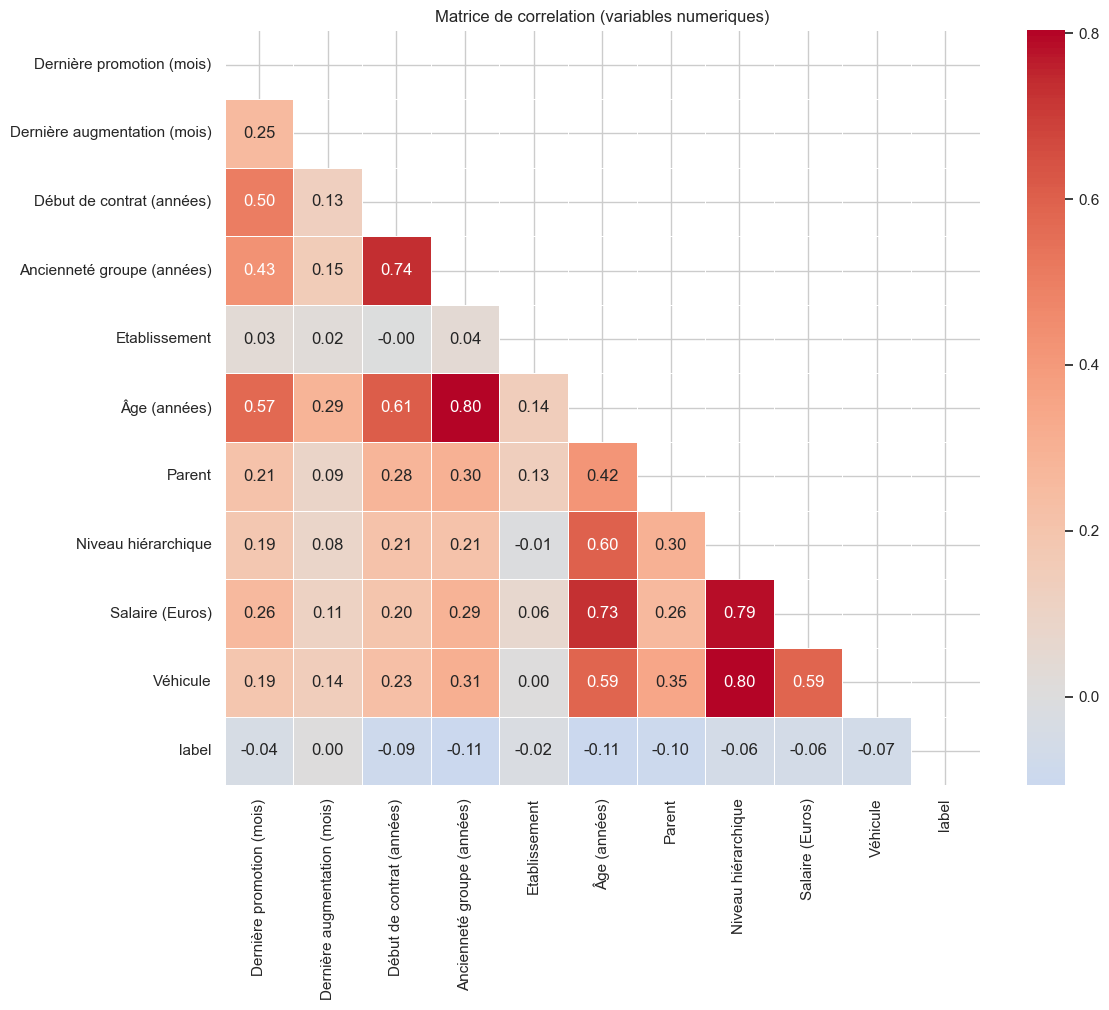

In [ ]:
columns_for_correlation = [
    c for c in df.select_dtypes(include="number").columns
    if c != "matricule"
]

correlation_matrix = df[columns_for_correlation].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matrice de correlation (variables numeriques)")
plt.tight_layout()
plt.show()

**Commentaire sur la matrice de correlation :**

Correlations notables :
- **Debut de contrat / Anciennete groupe** : Forte correlation positive attendue -- plus le contrat est ancien, plus l'anciennete dans le groupe est elevee.
- **Age / Anciennete groupe** et **Age / Debut de contrat** : Correlations positives moderees -- les employes plus ages ont logiquement plus d'anciennete.
- **Salaire / Niveau hierarchique** : Correlation positive -- un niveau hierarchique eleve s'accompagne d'un salaire plus eleve.
- **Salaire / Age** et **Salaire / Anciennete** : Correlations positives moderees -- la remuneration augmente avec l'experience.
- **Vehicule / Niveau hierarchique** et **Vehicule / Salaire** : Correlations positives -- l'attribution d'un vehicule est liee au niveau et au salaire.

Correlations avec la variable cible (`label`) :
- Les correlations avec `label` sont globalement **faibles**, ce qui est attendu pour un evenement rare (~3%). Les plus marquees concernent probablement l'age, l'anciennete et le salaire (negatives : les plus jeunes/moins anciens/moins bien payes demissionnent davantage).

### 1.7 Analyses complementaires : distributions par classe

On compare les distributions des variables numeriques entre les employes demissionnaires et non-demissionnaires pour identifier visuellement les variables discriminantes.

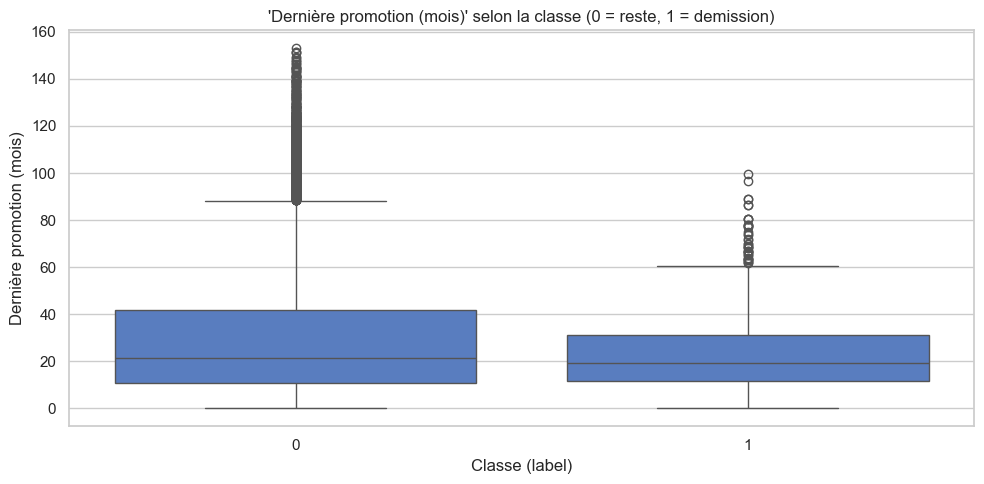

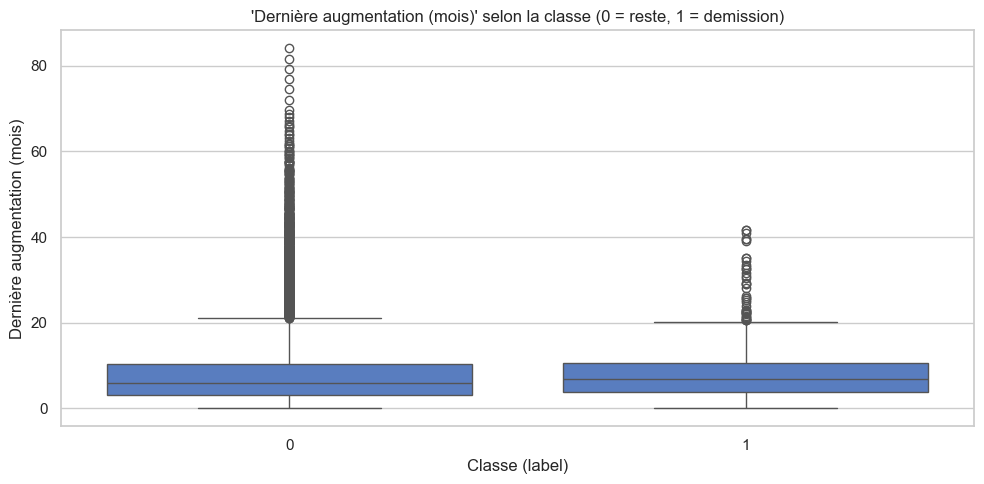

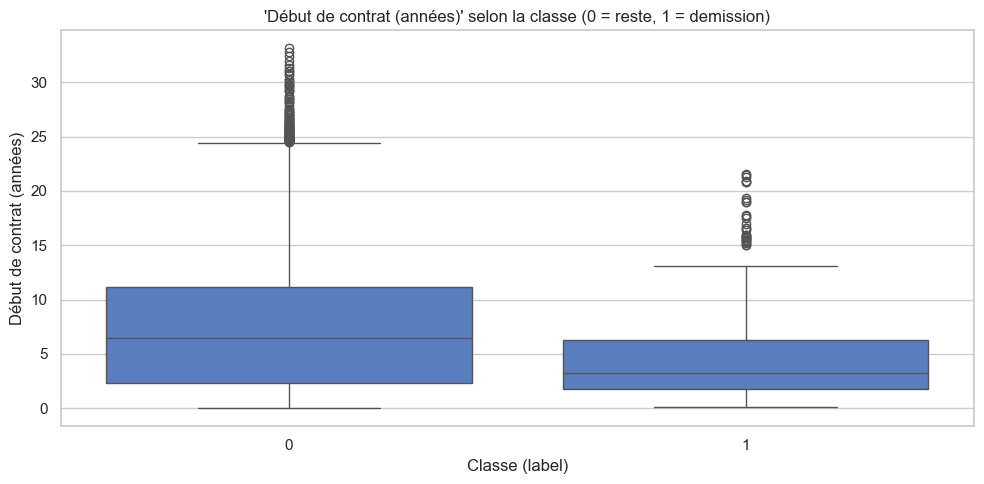

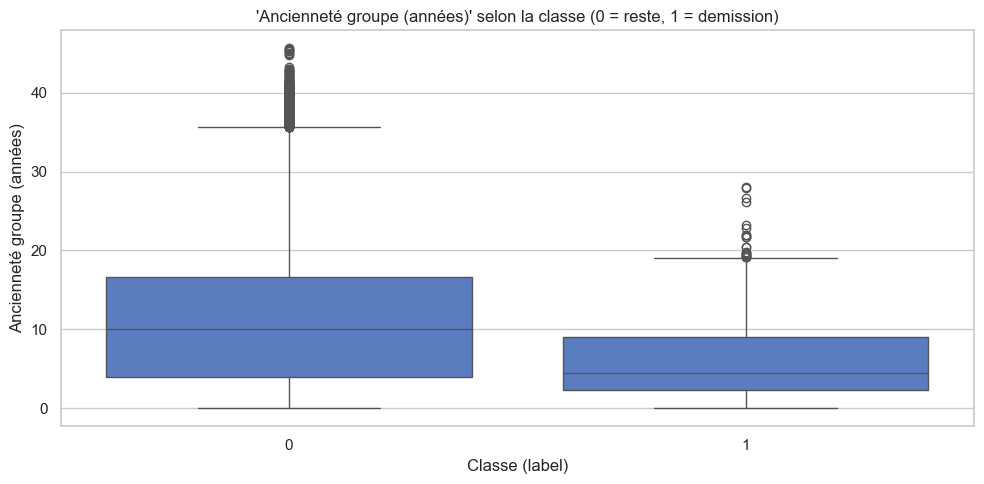

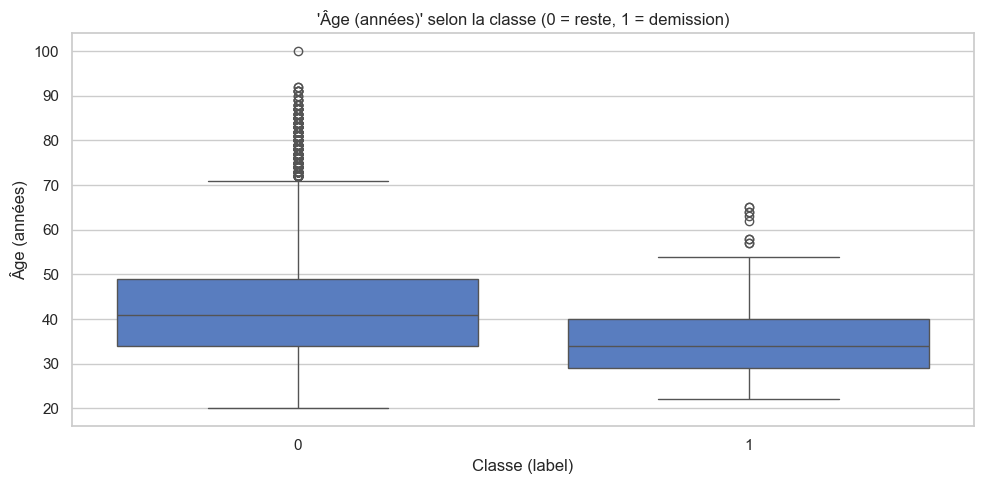

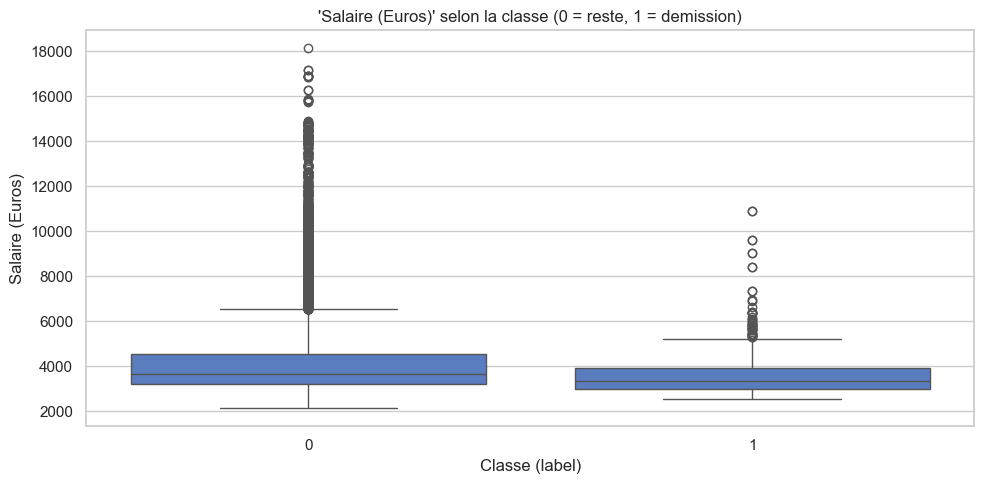

In [19]:
# Boxplots compares par classe pour chaque variable numerique continue
for col in numerical_columns:
    plot_boxplot_by_label(
        data=df,
        column=col,
        title=f"'{col}' selon la classe (0 = reste, 1 = demission)",
    )

In [20]:
# Taux de demission par variable categorielle
def compute_resignation_rate(
    data: pd.DataFrame,
    group_col: str,
    label_col: str = LABEL_COL,
) -> pd.DataFrame:
    """Calcule le taux de demission par modalite d'une variable categorielle."""
    rates = (
        data.groupby(group_col)[label_col]
        .agg(["sum", "count"])
        .rename(columns={"sum": "nb_demissions", "count": "effectif_total"})
    )
    rates["taux_demission_%"] = (rates["nb_demissions"] / rates["effectif_total"] * 100).round(2)
    return rates.sort_values("taux_demission_%", ascending=False)


for col in categorical_columns + ["Niveau hiérarchique", "Parent"]:
    print(f"--- Taux de demission par '{col}' ---")
    rates = compute_resignation_rate(df, col)
    display(rates)
    print()

--- Taux de demission par 'Famille d'emploi' ---


,nb_demissions,effectif_total,taux_demission_%
Famille d'emploi,,,
Etudes & Technique,180,4668,3.86
Production,387,10833,3.57
Commercial/Business,49,1682,2.91
Support,98,3876,2.53
IT,14,723,1.94
Matériel/Equipement,25,1548,1.61
Développement Immobilier,2,395,0.51
Management,0,132,0.00



--- Taux de demission par 'Statut marital' ---


,nb_demissions,effectif_total,taux_demission_%
Statut marital,,,
Célibataire,286,5111,5.60
Concubin,38,1053,3.61
PACS,122,4556,2.68
Union libre,26,1009,2.58
Marié(e),252,10251,2.46
Divorcé(e),21,1141,1.84
Séparé(e),8,488,1.64
Veuf(ve),2,165,1.21
ex PACS,0,83,0.00



--- Taux de demission par 'Niveau hiérarchique' ---


,nb_demissions,effectif_total,taux_demission_%
Niveau hiérarchique,,,
1,518,12823,4.04
2,214,8858,2.42
3,23,2156,1.07
4,0,20,0.00



--- Taux de demission par 'Parent' ---


,nb_demissions,effectif_total,taux_demission_%
Parent,,,
0,389,6663,5.84
1,366,17194,2.13


**Commentaire sur les analyses complementaires :**

Les boxplots confirment les tendances observees :
- Les **demissionnaires sont en moyenne plus jeunes**, avec moins d'anciennete et un salaire plus faible.
- Le **debut de contrat** est plus recent pour les demissionnaires, ce qui est coherent avec une moindre integration dans l'entreprise.
- Les variables de temps depuis derniere promotion/augmentation ne montrent pas de separation nette.

Les taux de demission par variable categorielle revelent :
- Des disparites possibles entre familles d'emploi (certains metiers plus touches que d'autres).
- Le niveau hierarchique 1 concentre probablement un taux de demission plus eleve.
- Les non-parents pourraient avoir un taux de demission plus eleve (moins d'attaches familiales).

---
## 2. Analyse des variables sensibles et biais potentiels

Dans le contexte de l'IA responsable, certaines variables peuvent introduire des biais discriminatoires dans un modele predictif. On distingue :
- Les **variables sensibles directes** : elles correspondent a des caracteristiques protegees par la loi (sexe, origine ethnique, religion, orientation sexuelle, handicap, etc.).
- Les **variables proxies** : elles ne sont pas sensibles en elles-memes mais permettent d'inferer, directement ou indirectement, une caracteristique sensible.

### 2.1 Identification des variables sensibles

In [ ]:
# Classification des variables selon leur sensibilite
variable_sensitivity = pd.DataFrame({
    "Variable": [
        "Age (annees)",
        "Statut marital",
        "Parent",
        "Salaire (Euros)",
        "Niveau hierarchique",
        "Vehicule",
        "Etablissement",
        "Famille d'emploi",
        "Derniere promotion (mois)",
        "Derniere augmentation (mois)",
        "Debut de contrat (annees)",
        "Anciennete groupe (annees)",
        "matricule",
    ],
    "Classification": [
        "Sensible directe",
        "Sensible directe",
        "Proxy",
        "Proxy",
        "Proxy",
        "Proxy",
        "Proxy potentiel",
        "Non sensible",
        "Non sensible",
        "Non sensible",
        "Non sensible",
        "Non sensible",
        "Identifiant (a exclure)",
    ],
    "Justification": [
        "L'age est un critere protege par la loi (discrimination liee a l'age). "
        "Un modele qui utilise l'age pourrait defavoriser les seniors ou les jeunes.",

        "Le statut marital peut reveler indirectement la situation familiale, "
        "l'orientation sexuelle (ex. PACS historiquement associe aux couples de meme sexe), "
        "ou le sexe (veuf/veuve). C'est un critere protege.",

        "La variable Parent (0/1) est un proxy du sexe : les femmes etant statistiquement "
        "plus impactees par la parentalite (conge maternite, temps partiel), cette variable "
        "peut permettre d'inferer le sexe et introduire un biais de genre.",

        "Le salaire est fortement correle au niveau hierarchique, a l'age et a l'anciennete. "
        "Il peut etre un proxy indirect de l'age (discrimination) et reflete potentiellement "
        "des inegalites salariales preexistantes (genre, origine).",

        "Le niveau hierarchique est correle au salaire et a l'age. Il peut etre un proxy "
        "de l'age et reflete potentiellement des plafonds de verre (genre, origine).",

        "L'attribution d'un vehicule de fonction depend du niveau hierarchique et du salaire. "
        "En tant que proxy de ces variables, il herite de leurs biais potentiels.",

        "Le code d'etablissement pourrait etre un proxy geographique, et donc potentiellement "
        "correle a l'origine ethnique ou au niveau socio-economique d'une zone.",

        "Variable liee a la gestion de carriere, non sensible a priori.",
        "Variable liee a la gestion de carriere, non sensible a priori.",
        "Variable liee a la gestion de carriere, non sensible a priori.",
        "Duree depuis l'embauche, variable professionnelle neutre.",
        "Duree d'anciennete dans le groupe, variable professionnelle neutre.",
        "Simple identifiant, aucun pouvoir predictif ni sensibilite.",
    ],
})

variable_sensitivity.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
)

,Variable,Classification,Justification
0,Age (annees),Sensible directe,L'age est un critere protege par la loi (discrimination liee a l'age). Un modele qui utilise l'age pourrait defavoriser les seniors ou les jeunes.
1,Statut marital,Sensible directe,"Le statut marital peut reveler indirectement la situation familiale, l'orientation sexuelle (ex. PACS historiquement associe aux couples de meme sexe), ou le sexe (veuf/veuve). C'est un critere protege."
2,Parent,Proxy,"La variable Parent (0/1) est un proxy du sexe : les femmes etant statistiquement plus impactees par la parentalite (conge maternite, temps partiel), cette variable peut permettre d'inferer le sexe et introduire un biais de genre."
3,Salaire (Euros),Proxy,"Le salaire est fortement correle au niveau hierarchique, a l'age et a l'anciennete. Il peut etre un proxy indirect de l'age (discrimination) et reflete potentiellement des inegalites salariales preexistantes (genre, origine)."
4,Niveau hierarchique,Proxy,"Le niveau hierarchique est correle au salaire et a l'age. Il peut etre un proxy de l'age et reflete potentiellement des plafonds de verre (genre, origine)."
5,Vehicule,Proxy,"L'attribution d'un vehicule de fonction depend du niveau hierarchique et du salaire. En tant que proxy de ces variables, il herite de leurs biais potentiels."
6,Etablissement,Proxy potentiel,"Le code d'etablissement pourrait etre un proxy geographique, et donc potentiellement correle a l'origine ethnique ou au niveau socio-economique d'une zone."
7,Famille d'emploi,Non sensible,"Variable liee a la gestion de carriere, non sensible a priori."
8,Derniere promotion (mois),Non sensible,"Variable liee a la gestion de carriere, non sensible a priori."
9,Derniere augmentation (mois),Non sensible,"Variable liee a la gestion de carriere, non sensible a priori."


### 2.2 Analyse approfondie des variables sensibles

#### Age

L'age est un critere protege. Analysons sa distribution par classe pour detecter un eventuel biais.

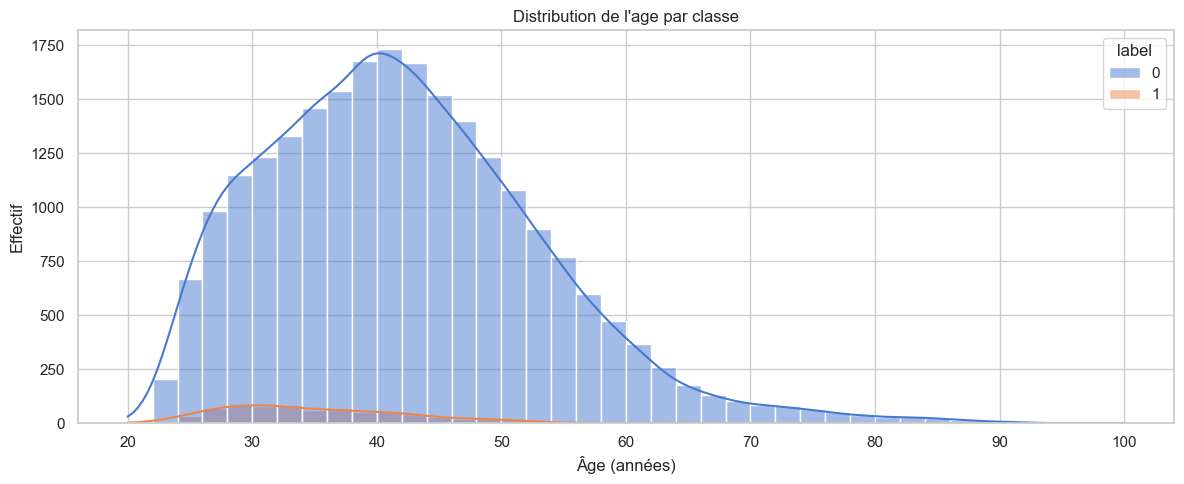

Taux de demission par tranche d'age :


C:\Users\clemm\AppData\Local\Temp\ipykernel_32100\393066934.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(group_col)[label_col]


,nb_demissions,effectif_total,taux_demission_%
tranche_age,,,
25-29,178,2693,6.61
30-34,195,3456,5.64
20-24,21,525,4.00
35-39,151,4128,3.66
40-44,117,4295,2.72
45-49,56,3425,1.64
50-54,27,2421,1.12
60+,6,1481,0.41
55-59,4,1432,0.28


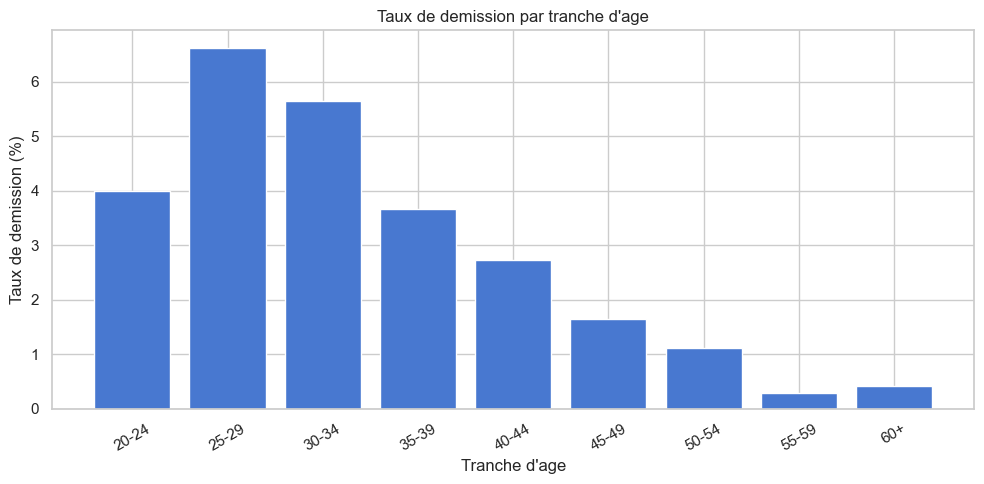

In [22]:
# Distribution de l'age par classe
plot_distribution(
    data=df,
    column="Âge (années)",
    title="Distribution de l'age par classe",
    hue=LABEL_COL,
    bins=40,
)

# Tranches d'age pour une analyse plus fine
age_bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
age_labels = ["20-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60+"]
df["tranche_age"] = pd.cut(df["Âge (années)"], bins=age_bins, labels=age_labels, right=False)

rates_age = compute_resignation_rate(df, "tranche_age")
print("Taux de demission par tranche d'age :")
display(rates_age)

fig, ax = plt.subplots(figsize=(10, 5))
rates_age_sorted = rates_age.sort_index()
ax.bar(rates_age_sorted.index.astype(str), rates_age_sorted["taux_demission_%"])
ax.set_title("Taux de demission par tranche d'age")
ax.set_xlabel("Tranche d'age")
ax.set_ylabel("Taux de demission (%)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Commentaire :** Le taux de demission est nettement plus eleve chez les **jeunes employes (20-29 ans)**, ce qui confirme que l'age est un facteur discriminant. Un modele entraine sur ces donnees risquerait de predire plus souvent la demission pour les jeunes, ce qui pourrait mener a des decisions RH biaisees (par ex. ne pas investir dans la formation des jeunes recrues).

#### Statut marital

Taux de demission par statut marital :


,nb_demissions,effectif_total,taux_demission_%
Statut marital,,,
Célibataire,286,5111,5.60
Concubin,38,1053,3.61
PACS,122,4556,2.68
Union libre,26,1009,2.58
Marié(e),252,10251,2.46
Divorcé(e),21,1141,1.84
Séparé(e),8,488,1.64
Veuf(ve),2,165,1.21
ex PACS,0,83,0.00


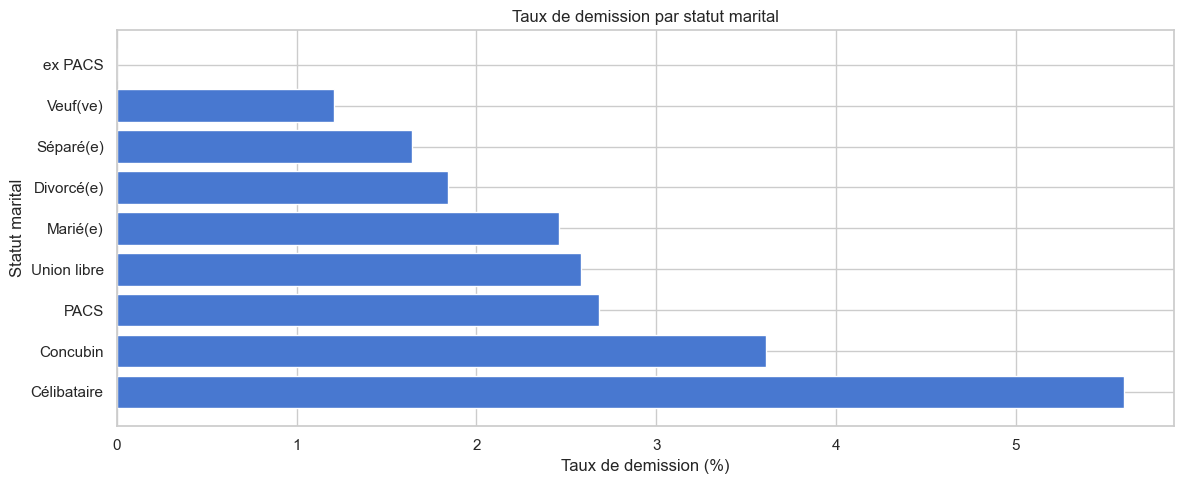

In [23]:
# Taux de demission par statut marital
rates_marital = compute_resignation_rate(df, "Statut marital")
print("Taux de demission par statut marital :")
display(rates_marital)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(rates_marital.index.astype(str), rates_marital["taux_demission_%"])
ax.set_title("Taux de demission par statut marital")
ax.set_xlabel("Taux de demission (%)")
ax.set_ylabel("Statut marital")
plt.tight_layout()
plt.show()

**Commentaire :** Le statut marital montre des disparites dans le taux de demission. Les celibataires ont potentiellement un taux plus eleve. Par ailleurs, cette variable est problematique a plusieurs titres :
- Elle peut servir de **proxy pour l'orientation sexuelle** (ex. PACS historiquement associe aux couples de meme sexe, meme si c'est de moins en moins le cas).
- Les modalites genrees ("Veuf/Veuve") permettent d'inferer le **sexe**.
- Elle revele la **situation familiale**, critere protege par le droit du travail francais.

#### Parent

Taux de demission par statut parental :


,nb_demissions,effectif_total,taux_demission_%
Parent,,,
Non-parent,389,6663,5.84
Parent,366,17194,2.13


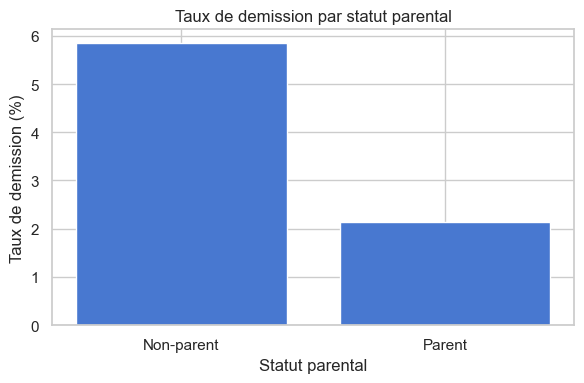

In [24]:
# Taux de demission par statut parental
rates_parent = compute_resignation_rate(df, "Parent")
rates_parent.index = rates_parent.index.map({0: "Non-parent", 1: "Parent"})
print("Taux de demission par statut parental :")
display(rates_parent)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(rates_parent.index.astype(str), rates_parent["taux_demission_%"])
ax.set_title("Taux de demission par statut parental")
ax.set_xlabel("Statut parental")
ax.set_ylabel("Taux de demission (%)")
plt.tight_layout()
plt.show()

**Commentaire :** La variable `Parent` est un **proxy du sexe**. Dans la societe, la parentalite impacte differemment les hommes et les femmes (conges maternite, temps partiel subi, etc.). Un modele utilisant cette variable pourrait indirectement discriminer selon le genre. De plus, la situation familiale est un critere protege en droit du travail francais (article L1132-1 du Code du travail).

### 2.3 Correlation entre variables sensibles et proxies

Analysons les correlations entre les variables sensibles identifiees et les autres variables pour confirmer les liens de proxy.

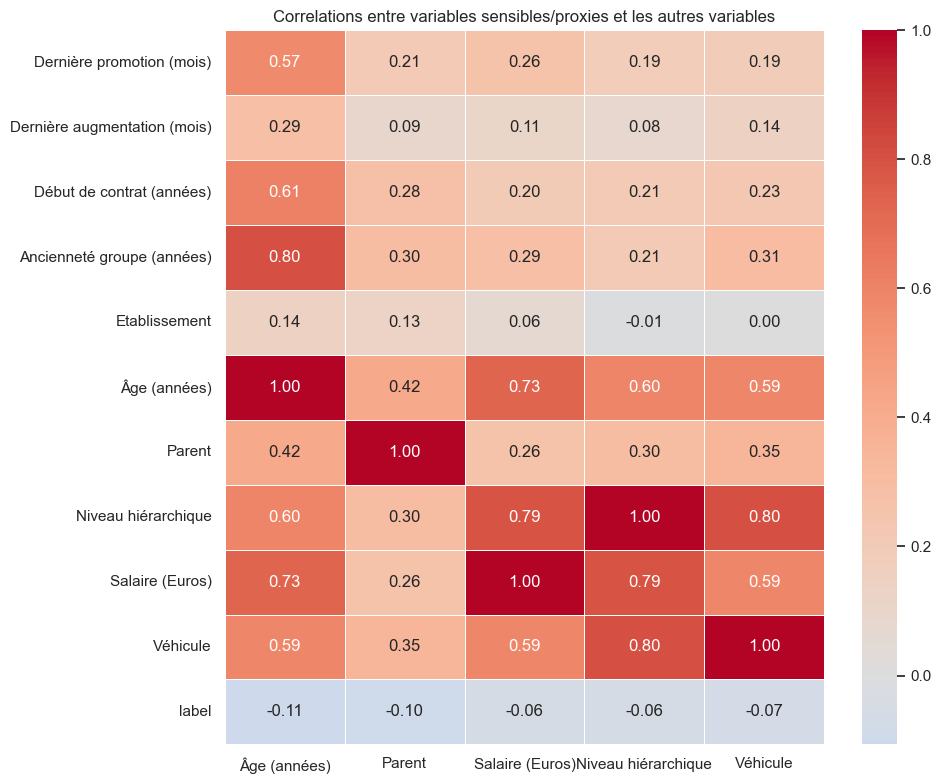

In [25]:
# Correlation des variables sensibles/proxies avec les autres variables numeriques
sensitive_and_proxy_cols = ["Âge (années)", "Parent", "Salaire (Euros)", "Niveau hiérarchique", "Véhicule"]

corr_subset = df[columns_for_correlation].corr()[sensitive_and_proxy_cols]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_subset,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlations entre variables sensibles/proxies et les autres variables")
plt.tight_layout()
plt.show()

**Commentaire :** Cette heatmap confirme les liens de proxy :
- **Salaire**, **niveau hierarchique** et **vehicule** sont fortement correles entre eux et avec l'**age** et l'**anciennete**. Meme en supprimant l'age du modele, ces variables permettent de le reconstruire partiellement.
- **Parent** est correle a l'**age** (les personnes plus agees ont plus de chances d'etre parents), au **niveau hierarchique** et au **salaire**.
- La chaine de proxy est donc : Age -> Anciennete -> Salaire -> Niveau hierarchique -> Vehicule. Supprimer une seule de ces variables ne suffit pas a eliminer le biais lie a l'age.

### 2.4 Synthese des variables sensibles et recommandations

| Variable | Type | Risque |
|---|---|---|
| `Age (annees)` | Sensible directe | Discrimination liee a l'age (critere protege) |
| `Statut marital` | Sensible directe | Revele situation familiale, potentiellement genre et orientation sexuelle |
| `Parent` | Proxy (sexe, situation familiale) | Impact differentiel selon le genre, critere protege |
| `Salaire (Euros)` | Proxy (age, genre) | Reflete des inegalites preexistantes, correle a l'age |
| `Niveau hierarchique` | Proxy (age, genre) | Plafond de verre potentiel, correle a l'age et au salaire |
| `Vehicule` | Proxy (niveau, salaire) | Herite des biais du niveau hierarchique |
| `Etablissement` | Proxy potentiel (geographie) | Pourrait refleter des disparites geographiques/sociales |

**Recommandations pour la phase de modelisation :**
1. **Ne pas utiliser** directement les variables sensibles (`Age`, `Statut marital`) comme features du modele.
2. **Etre vigilant** avec les proxies (`Parent`, `Salaire`, `Niveau hierarchique`) : meme en supprimant les variables sensibles, les proxies peuvent reintroduire le biais.
3. **Mesurer l'equite** du modele a posteriori (demographic parity, equalized odds) sur les groupes sensibles.
4. **Documenter** les choix faits et leurs justifications pour assurer la transparence du systeme.

---
## 3. Apprentissage automatique

*(A completer lors de la prochaine seance.)*

Pistes prevues :
- Pre-traitement des donnees (encodage des variables categorielles, normalisation, gestion du desequilibre)
- Entrainement de modeles (regression logistique, arbre de decision, random forest, etc.)
- Evaluation avec des metriques adaptees au desequilibre (F1-score, AUC-ROC, matrice de confusion)
- Analyse de l'equite (fairness metrics) sur les groupes sensibles identifies en partie 2
- Explicabilite des predictions (SHAP, LIME)

In [26]:
# Nettoyage : suppression de la colonne temporaire creee pour l'analyse
df = df.drop(columns=["tranche_age"])